In [29]:
import logging

import matplotlib.pyplot as plt
import torch

import specter
from specter.fft import fft2
from specter.imagegenerator import ImageGenerator
from specter.pdb import PDB
from specter.plots import plot3d
from specter.potential import PotentialBuilder
from specter.arrays import radial_profile_2d, center_crop
from specter.progress import track
from specter.cryosparc import extract_parameters_from_csfile
from cryosparc.dataset import Dataset

import mrcfile

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
specter.set_verbosity(logging.INFO)

## Required parameters

In [3]:
n = 256  # number of pixels in image
pdb_code = "6bdf"
dose_per_angstrom = 53  # e-/A^2, from EMDB Experiment tab.
num_frames = int(dose_per_angstrom)  # usually ~ 1-2 e-/A^2/frame

## Specify .cs from CryoSPARC Job that contains rotations and aberrations

In [4]:
cs_path = "/scratch/loh/joel/cryosparc_tutorial/CS-cryosparc-tutorial/J35/J35_passthrough_particles.cs"
df = Dataset.load(cs_path)
df

,uid,alignments3D/split,alignments3D/shift,alignments3D/pose,alignments3D/psize_A,alignments3D/error,alignments3D/error_min,alignments3D/resid_pow,alignments3D/slice_pow,alignments3D/image_pow,alignments3D/cross_cor,alignments3D/alpha,alignments3D/alpha_min,alignments3D/weight,alignments3D/pose_ess,alignments3D/shift_ess,alignments3D/class_posterior,alignments3D/class,alignments3D/class_ess,ctf/type,ctf/exp_group_id,ctf/accel_kv,ctf/cs_mm,ctf/amp_contrast,ctf/df1_A,ctf/df2_A,ctf/df_angle_rad,ctf/phase_shift_rad,ctf/scale,ctf/scale_const,ctf/shift_A,ctf/tilt_A,ctf/trefoil_A,ctf/tetra_A,ctf/anisomag,ctf/bfactor,alignments2D/split,alignments2D/shift,alignments2D/pose,alignments2D/psize_A,alignments2D/error,alignments2D/error_min,alignments2D/resid_pow,alignments2D/slice_pow,alignments2D/image_pow,alignments2D/cross_cor,alignments2D/alpha,alignments2D/alpha_min,alignments2D/weight,alignments2D/pose_ess,alignments2D/shift_ess,alignments2D/class_posterior,alignments2D/class,alignments2D/class_ess,motion/type,motion/path,motion/idx,motion/frame_start,motion/frame_end,motion/zero_shift_frame,motion/psize_A,location/micrograph_uid,location/exp_group_id,location/micrograph_path,location/micrograph_shape,location/micrograph_psize_A,location/center_x_frac,location/center_y_frac,location/min_dist_A,pick_stats/ncc_score,pick_stats/power,pick_stats/template_idx,pick_stats/angle_rad
0,5914885907324368174,0,[0.04 0.2 ],[-0.41724277 -2.0792015 -2.2404885 ],1.1300781965255737,17906.08984375,0.0,0.0,138.5609588623047,18067.146484375,299.6171875,1.0,1.081174612045288,0.0,0.0,0.0,1.0,0,1.0,spline,0,300.0,2.700000047683716,0.10000000149011612,16151.65234375,16117.2060546875,-1.4837499856948853,0.0,1.0,1.0,[-0.1280566 -0.01920988],[-6909.15 -318.6182],[-3807.0818 837.0518],[ 45772.824 -82124.27 30165.68 98245.05 ],[-2.2277334e-03 -7.3947708e-06 1.9973399e-04 2.9885960e-03],0.0,1,[-0.64 -0.64],3.189678192138672,1.1300781965255737,3029.663330078125,0.0,0.0,91.32645416259766,3126.40478515625,188.06787109375,1.0,1.0296461582183838,0.0,0.0,0.0,0.9999996423721313,8,1.0000007152557373,particle,J18/reconstructed/10113413282700799272_motion.npy,0,0,38,0,0.6575000286102295,10113413282700799272,0,J2/motioncorrected/010113413282700799272_14sep05c_c_00003gr_00014sq_00011hl_00002es.frames_patch_aligned_doseweighted.mrc,[7676 7420],0.6575000286102295,0.882758617401123,0.20499999821186066,95.0,0.6870935559272766,1027.4305419921875,0,4.188790321350098
1,15840953186430191012,1,[0.2 0.04],[-2.5911126 -0.17180584 2.4017756 ],1.1300781965255737,18950.53515625,0.0,0.0,138.31304931640625,19207.5234375,395.30078125,1.0,1.4290075302124023,0.0,0.0,0.0,1.0,0,1.0,spline,0,300.0,2.700000047683716,0.10000000149011612,15993.166015625,15957.265625,-1.488160252571106,0.0,1.0,1.0,[-0.1280566 -0.01920988],[-6909.15 -318.6182],[-3807.0818 837.0518],[ 45772.824 -82124.27 30165.68 98245.05 ],[-2.2277334e-03 -7.3947708e-06 1.9973399e-04 2.9885960e-03],0.0,1,[3.2 0.64],3.2537922859191895,1.1300781965255737,3370.02099609375,0.0,0.0,84.66850280761719,3487.969482421875,202.616943359375,1.0,1.196530818939209,0.0,0.0,0.0,0.9999994039535522,14,1.0000011920928955,particle,J18/reconstructed/10113413282700799272_motion.npy,1,0,38,0,0.6575000286102295,10113413282700799272,0,J2/motioncorrected/010113413282700799272_14sep05c_c_00003gr_00014sq_00011hl_00002es.frames_patch_aligned_doseweighted.mrc,[7676 7420],0.6575000286102295,0.1862068921327591,0.2150000035762787,95.0,0.6749038100242615,1140.7061767578125,0,5.759586334228516
2,5195341372377992721,0,[-0.12 0.2 ],[ 1.826752 -1.2447158 -2.1002388],1.1300781965255737,17766.2578125,0.0,0.0,137.2856903076172,17968.2421875,339.26953125,1.0,1.2356332540512085,0.0,0.0,0.0,1.0,0,1.0,spline,0,300.0,2.700000047683716,0.10000000149011612,16286.2294921875,16253.748046875,-1.4773463010787964,0.0,1.0,1.0,[-0.1280566 -0.01920988],[-6909.15 -318.6182],[-3807.0818 837.0518],[ 45772.824 -82124.27 30165.68 98245.05 ],[-2.2277334e-03 -7.3947708e-06 1.9973399e-04 2.9885960e

In [5]:
(
    energy_kev,
    pixel_size,
    alpha,
    rotations,
    translations_A,
    ctf_params,
    scale,
    anisomag,
    indices,
    split,
) = extract_parameters_from_csfile(cs_path)

## Generate particle scattering potential

In [6]:
# fetch pdb file
assembly = True  # True: fetches assembly. False: fetches subunit. int: fetches specific assembly #int
pdb = PDB(pdb_code, assembly=True, savefolder="../pdb-data/")
# pdb = PDB(
#     "/scratch/loh/joel/czii/russo-scattering-factors/simulated_dataset/8el9_sim_1_cat_params.cif"
# )

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

In [7]:
# Samples 3D scattering potential onto specified grid
device = "cpu"
pb = PotentialBuilder(n, pixel_size.item(), pdb.atomic_numbers).to(device)

In [8]:
with torch.no_grad():
    V = pb(pdb.coordinates).clone()

Building element ...:   0%|          | 0/4 [00:00<?, ?it/s]

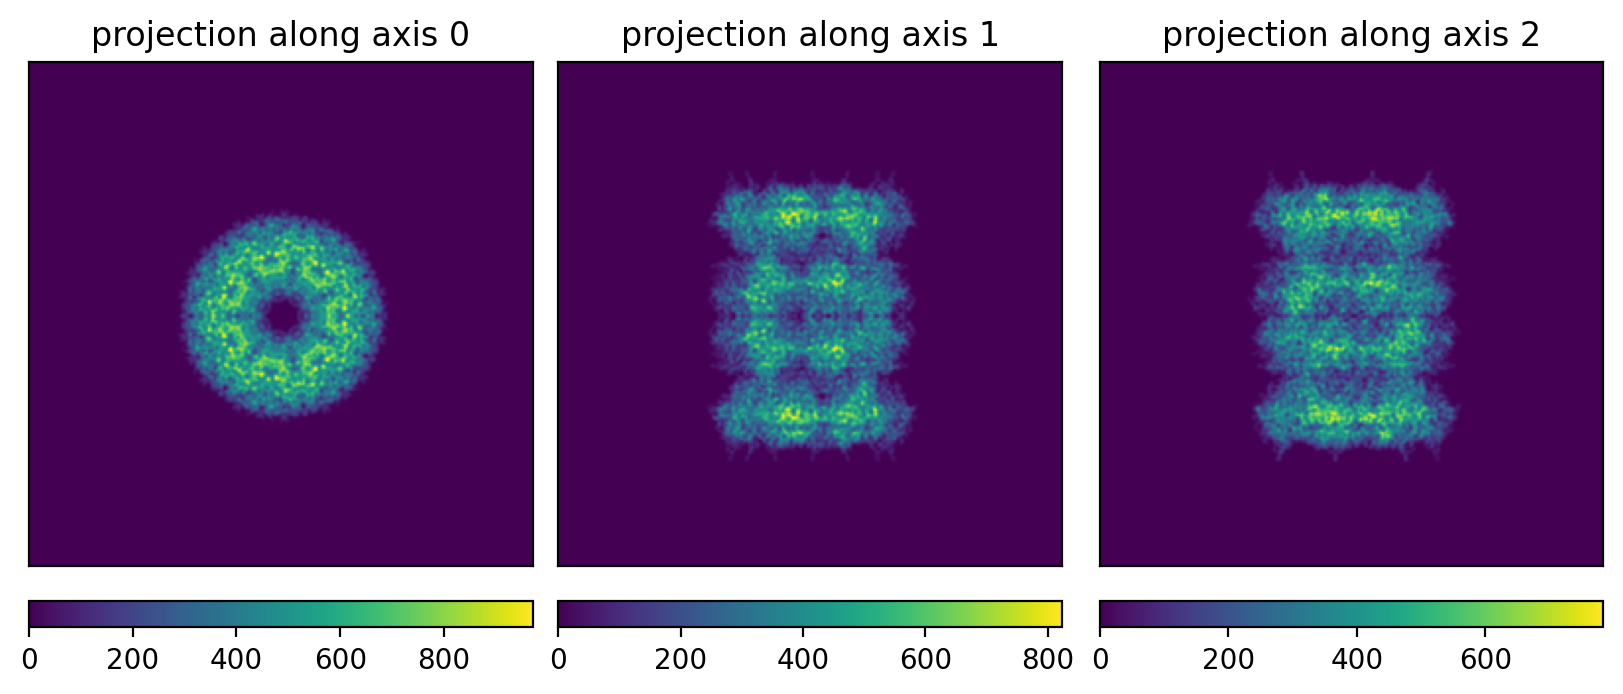

In [9]:
plot3d(V)

## Generate particles
Note: adjust ```coincidence_radius``` to match the contrast of your simulated images to the experiments.

In [13]:
n_particles = 10  # number of particles
# n_particles = len(df)  # number of particles
device = "cuda:3"  # choose cpu if you run out of cuda memory.

In [14]:
# Scattering model: 'multislice', 'firstborn', 'projection', 'ctf'
scattering_model = "multislice"

# Aberration model: 'holography' or 'ctf'
aberration_model = "holography"

# Noise model: 'poisson' or None
noise_model = "poisson"
# noise_model = None

# Coincidence radius in angstroms.
# Higher values suppress lower spatial frequencies.
# Set to 0 to recover default Poisson behaviour.
coincidence_radius = 2.1

# Ice model:
#   'random' : fast, worst accuracy
#   'ap'     : alternating projection. moderate speed, low accuracy
#   'gd'     : gradient descent. slow, highest accuracy
#   'mcmc'   : monte carlo markov chain. slowest, medium accuracy, under development.
#   None     : disable ice
ice_model = "gd"
# ice_model = None
num_unique_icecubes = 1

ice_thickness = 0  # angstroms, set to 0 for minimum ice thickness = particle box size

crowd_min_distance = pdb.max_diameter  # angstroms, set to None for no crowding
# crowd_min_distance = None

crowd_max_distance_z = None  # if None, defaults to ice_thickness which would result in too many particles above each other.

# pad_fft = False  # True to avoid edge artifacts when if crowd_min_distance is not None
pad_fft = True

detector_model = None
# detector_model = "perfect"  # 'perfect', 'k3_300kv', 'k3_200kv'

model = ImageGenerator(
    V,
    pixel_size.item(),
    rotations,
    translations_A,
    ctf_params,
    energy_kev,
    dose_per_angstrom,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    ews_curvature_sign="positive",
    alpha=alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=crowd_max_distance_z,
    pad_fft=pad_fft,
    detector_model=detector_model,
    verbose=False,
    coincidence_radius=coincidence_radius,
    num_frames=num_frames,
    num_unique_icecubes=num_unique_icecubes,
).to(device)

In [23]:
model.save_clean_exitwaves = True

In [24]:
idx = torch.arange(n_particles)
images = []
batchsize = 5  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in track(range(0, n_particles, batchsize), description="Generating images"):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

Generating images:   0%|          | 0/2 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/10 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/11 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/10 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/9 [00:00<?, ?it/s]

...

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

torch.Size([10, 256, 256])

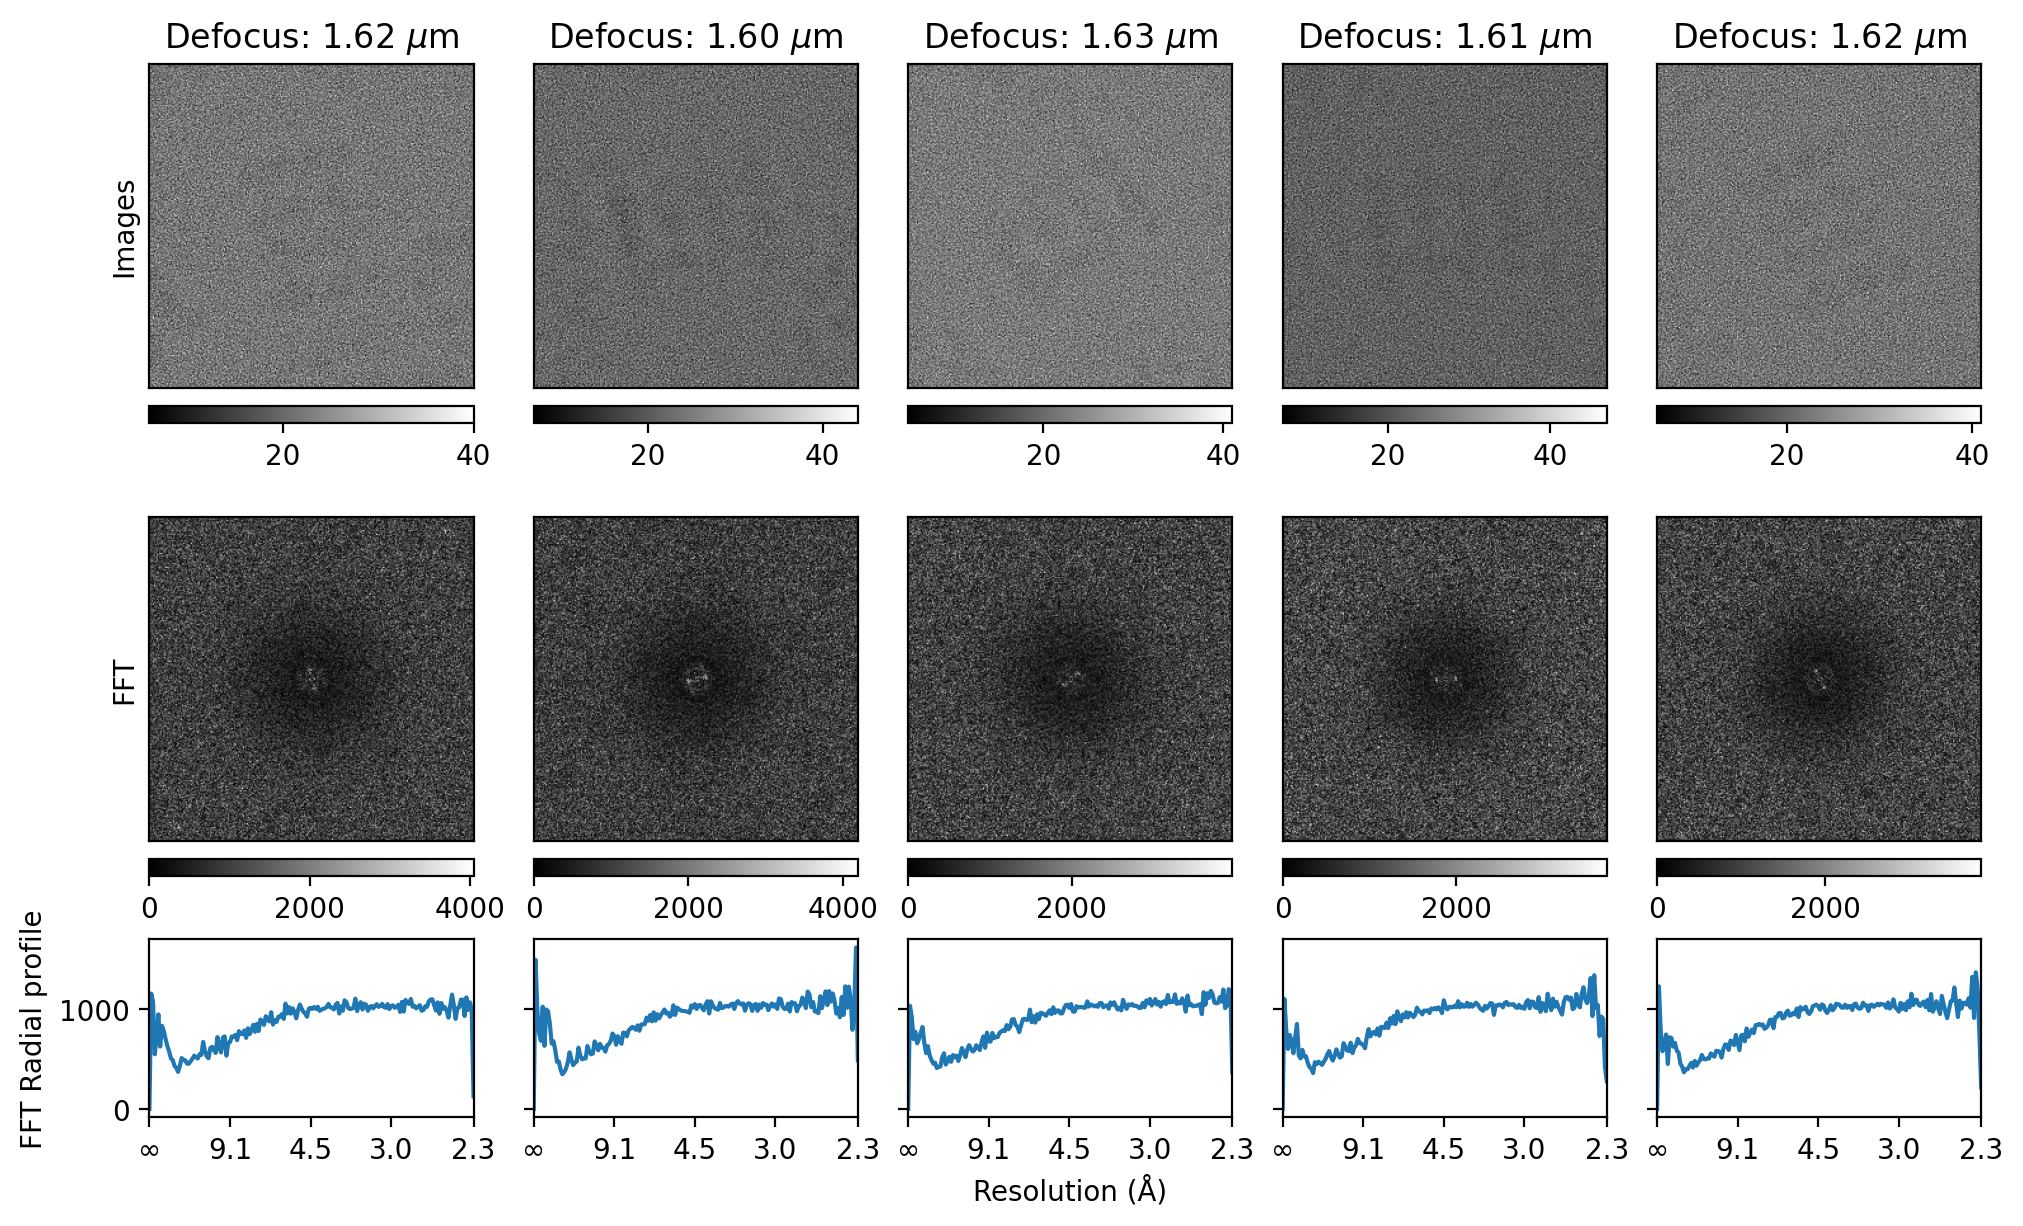

In [25]:
fig, axes = plt.subplots(
    3,
    5,
    dpi=200,
    constrained_layout=True,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [2, 2, 1]},
)
# after creating the axes, share y across the last row
for ax in axes[2, 1:]:
    ax.sharey(axes[2, 0])
    plt.setp(ax.get_yticklabels(), visible=False)

for i in range(5):
    ax = axes[0, i]
    im = ax.imshow(images[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params['dfu'][i] / 10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[1, i]
    im = ax.imshow(
        torch.abs(fft2(images[i] - torch.mean(images[i]), shift=True)),
        cmap="grey",
        # vmax=5000,
    )
    ax.set(xticks=[], yticks=[])
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[2, i]
    profile = radial_profile_2d(
        torch.abs(fft2(images[i] - torch.mean(images[i]), shift=True))
    )
    n = len(profile)
    ax.plot(profile.numpy() if hasattr(profile, "numpy") else profile)

    # X ticks: 6 ticks from 0 (inf) to n-1 (Nyquist)
    tick_positions = [int(j * (n - 1) / 4) for j in range(5)]
    # Spatial frequency in 1/Å: ranges from 0 to 1/(2*dx)
    # Avoid division by zero at position 0 (inf)
    tick_labels = []
    for pos in tick_positions:
        if pos == 0:
            tick_labels.append("∞")
        else:
            freq = (pos / (n - 1)) * (1 / (2 * pixel_size))  # 1/Å
            resolution = 1 / freq  # Å
            tick_labels.append(f"{resolution:.1f}")

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(0, n - 1)

axes[0, 0].set(ylabel="Images")
axes[1, 0].set(ylabel="FFT")
axes[2, 0].set(ylabel="FFT Radial profile")
axes[2, 2].set_xlabel("Resolution (Å)")

plt.show()

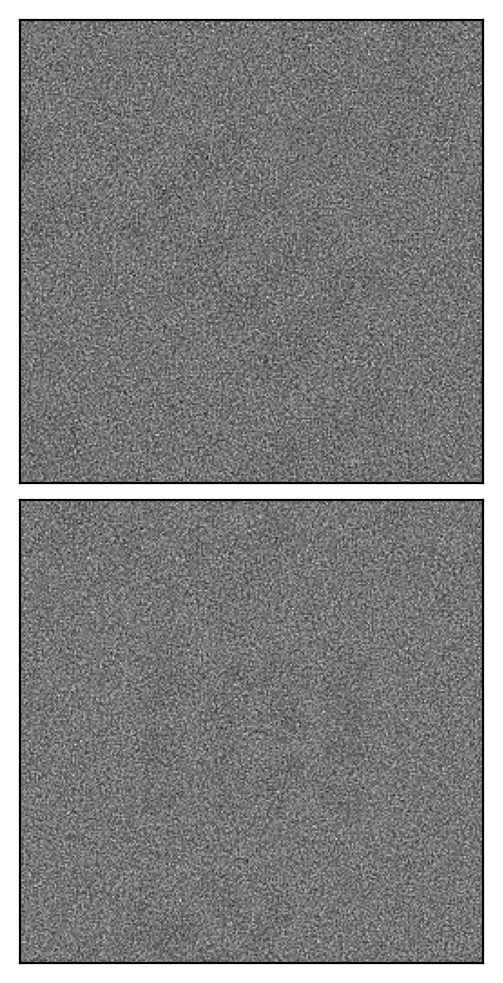

In [32]:
fig, axes = plt.subplots(2, 1, constrained_layout=True, dpi=200)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
ax = axes[0]
ax.imshow(center_crop(image[0].cpu(), 256), cmap="grey")
ax = axes[1]
ax.imshow(center_crop(image[1].cpu(), 256), cmap="grey")

## Compare with experimental particles (if available)

In [17]:
with mrcfile.mmap(
    "/scratch/loh/joel/cryosparc_tutorial/CS-cryosparc-tutorial/J35/restack/batch_0_restacked.mrc"
) as mrc:
    exp = torch.as_tensor(mrc.data[...].copy())

In [18]:
# note that experimental images are always flipped.
exp_flipped = -exp

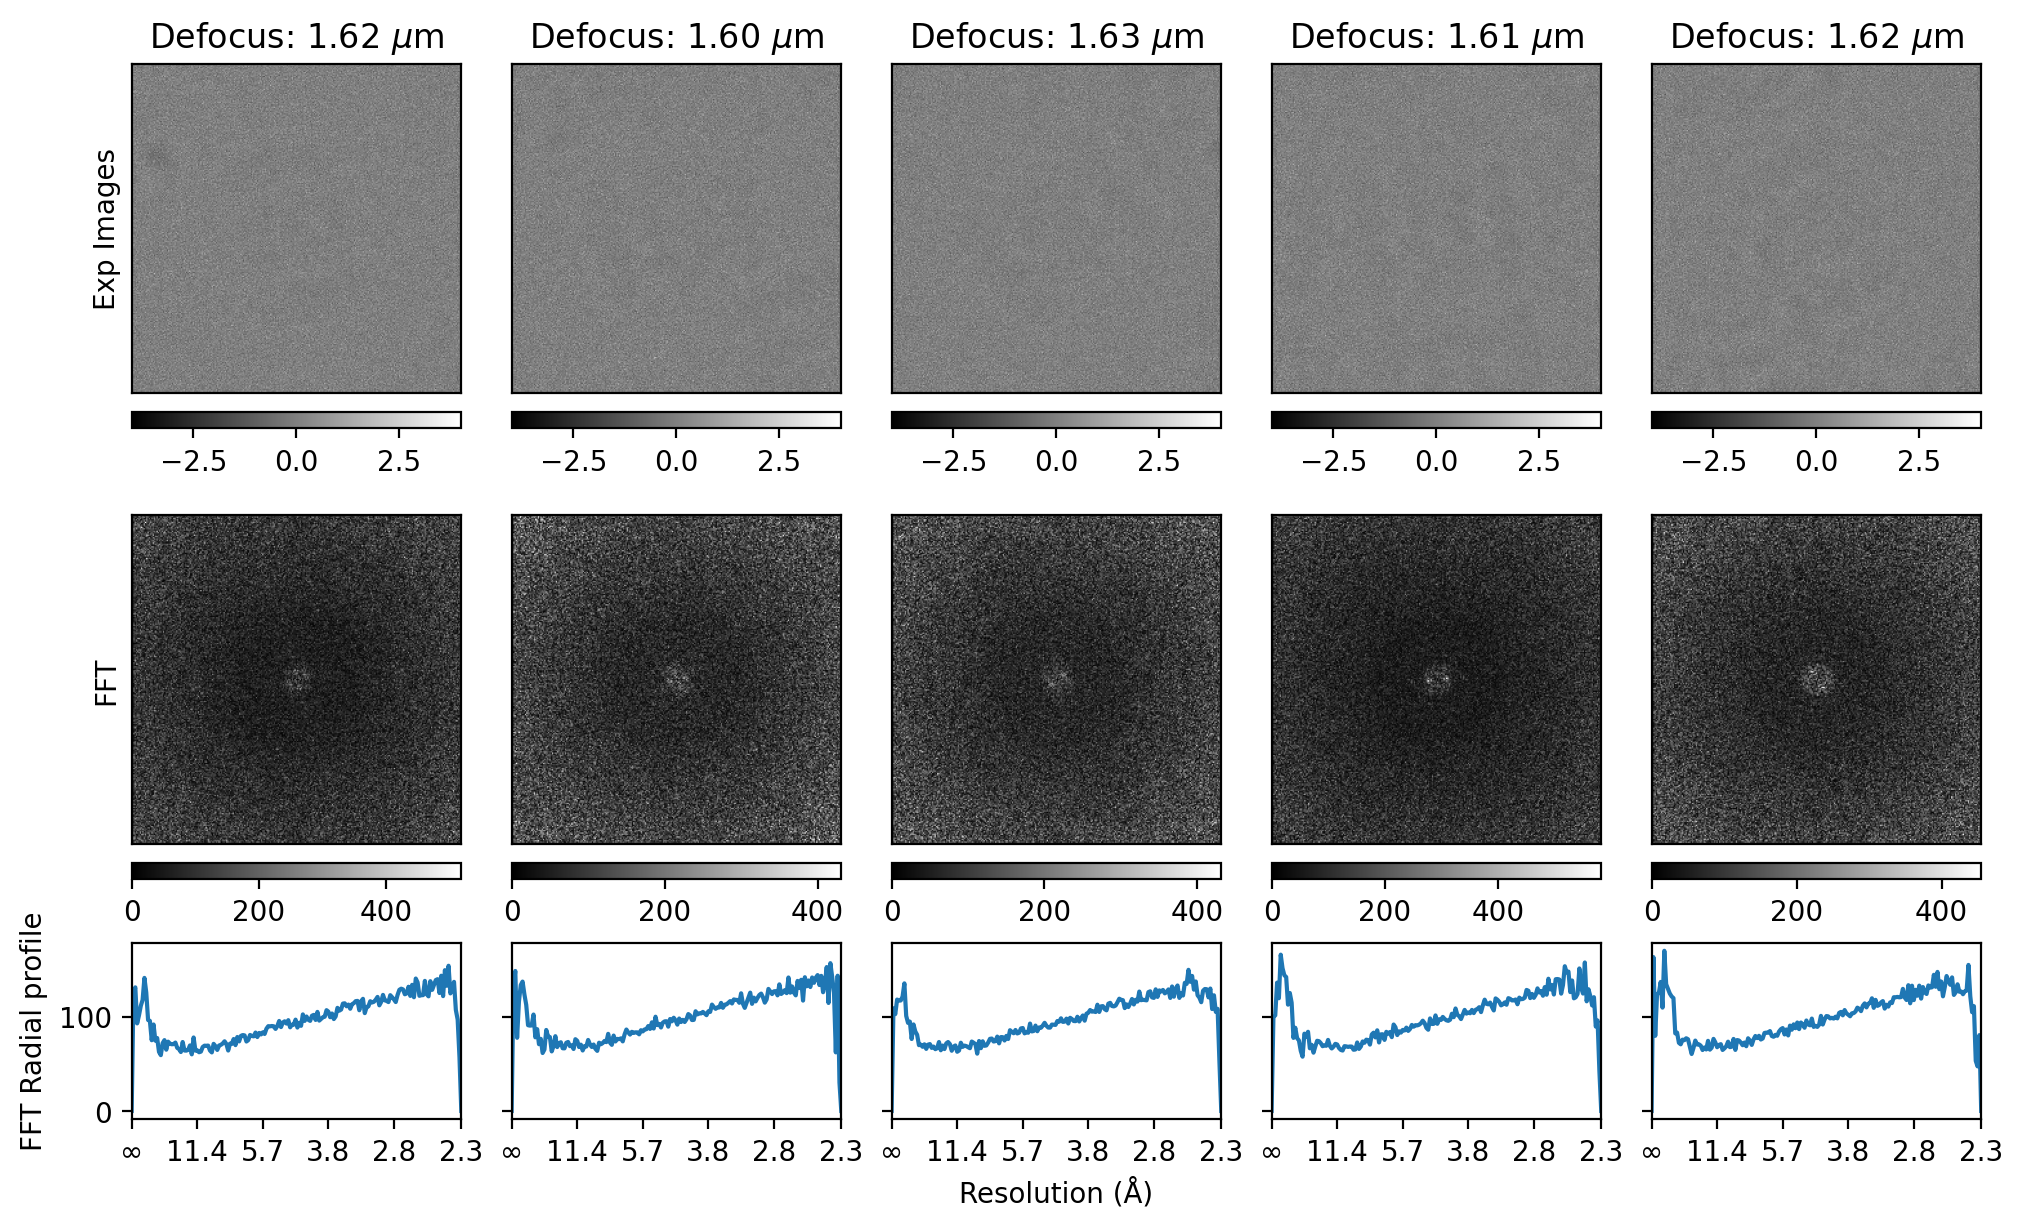

In [19]:
fig, axes = plt.subplots(
    3,
    5,
    dpi=200,
    constrained_layout=True,
    figsize=(10, 6),
    gridspec_kw={"height_ratios": [2, 2, 1]},
)
# after creating the axes, share y across the last row
for ax in axes[2, 1:]:
    ax.sharey(axes[2, 0])
    plt.setp(ax.get_yticklabels(), visible=False)

for i in range(5):
    ax = axes[0, i]
    im = ax.imshow(exp_flipped[i], cmap="grey", vmin=-4, vmax=4)
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params['dfu'][i] / 10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[1, i]
    im = ax.imshow(
        torch.abs(fft2(exp_flipped[i] - torch.mean(exp_flipped[i]), shift=True)),
        cmap="grey",
    )
    ax.set(xticks=[], yticks=[])
    fig.colorbar(im, ax=ax, location="bottom")

    ax = axes[2, i]
    profile = radial_profile_2d(
        torch.abs(fft2(exp_flipped[i] - torch.mean(exp_flipped[i]), shift=True))
    )
    n = len(profile)
    ax.plot(profile.numpy() if hasattr(profile, "numpy") else profile)

    # X ticks: 6 ticks from 0 (inf) to n-1 (Nyquist)
    n_ticks = 7
    tick_positions = [int(j * (n - 1) / (n_ticks - 2)) for j in range(n_ticks - 1)]
    # Spatial frequency in 1/Å: ranges from 0 to 1/(2*dx)
    # Avoid division by zero at position 0 (inf)
    tick_labels = []
    for pos in tick_positions:
        if pos == 0:
            tick_labels.append("∞")
        else:
            freq = (pos / (n - 1)) * (1 / (2 * pixel_size))  # 1/Å
            resolution = 1 / freq  # Å
            tick_labels.append(f"{resolution:.1f}")

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(0, n - 1)

axes[0, 0].set(ylabel="Exp Images")
axes[1, 0].set(ylabel="FFT")
axes[2, 0].set(ylabel="FFT Radial profile")
axes[2, 2].set_xlabel("Resolution (Å)")

plt.show()